In [ ]:
import skimage as ski
import numpy as np
import matplotlib.pyplot as plt
import random
import rasterio
from pathlib import Path

In [ ]:
dataset_path = Path("/content/drive/MyDrive/Project1 : Tree_cover_segmentation/05-treecover_segmentation_satellite_bengaluru")
tiles_path = dataset_path / "tiles"
masks_path = dataset_path / "masks"

In [ ]:
tile_files = list(tiles_path.glob("tile_*.tif"))

selected_files = random.sample(tile_files, 6)

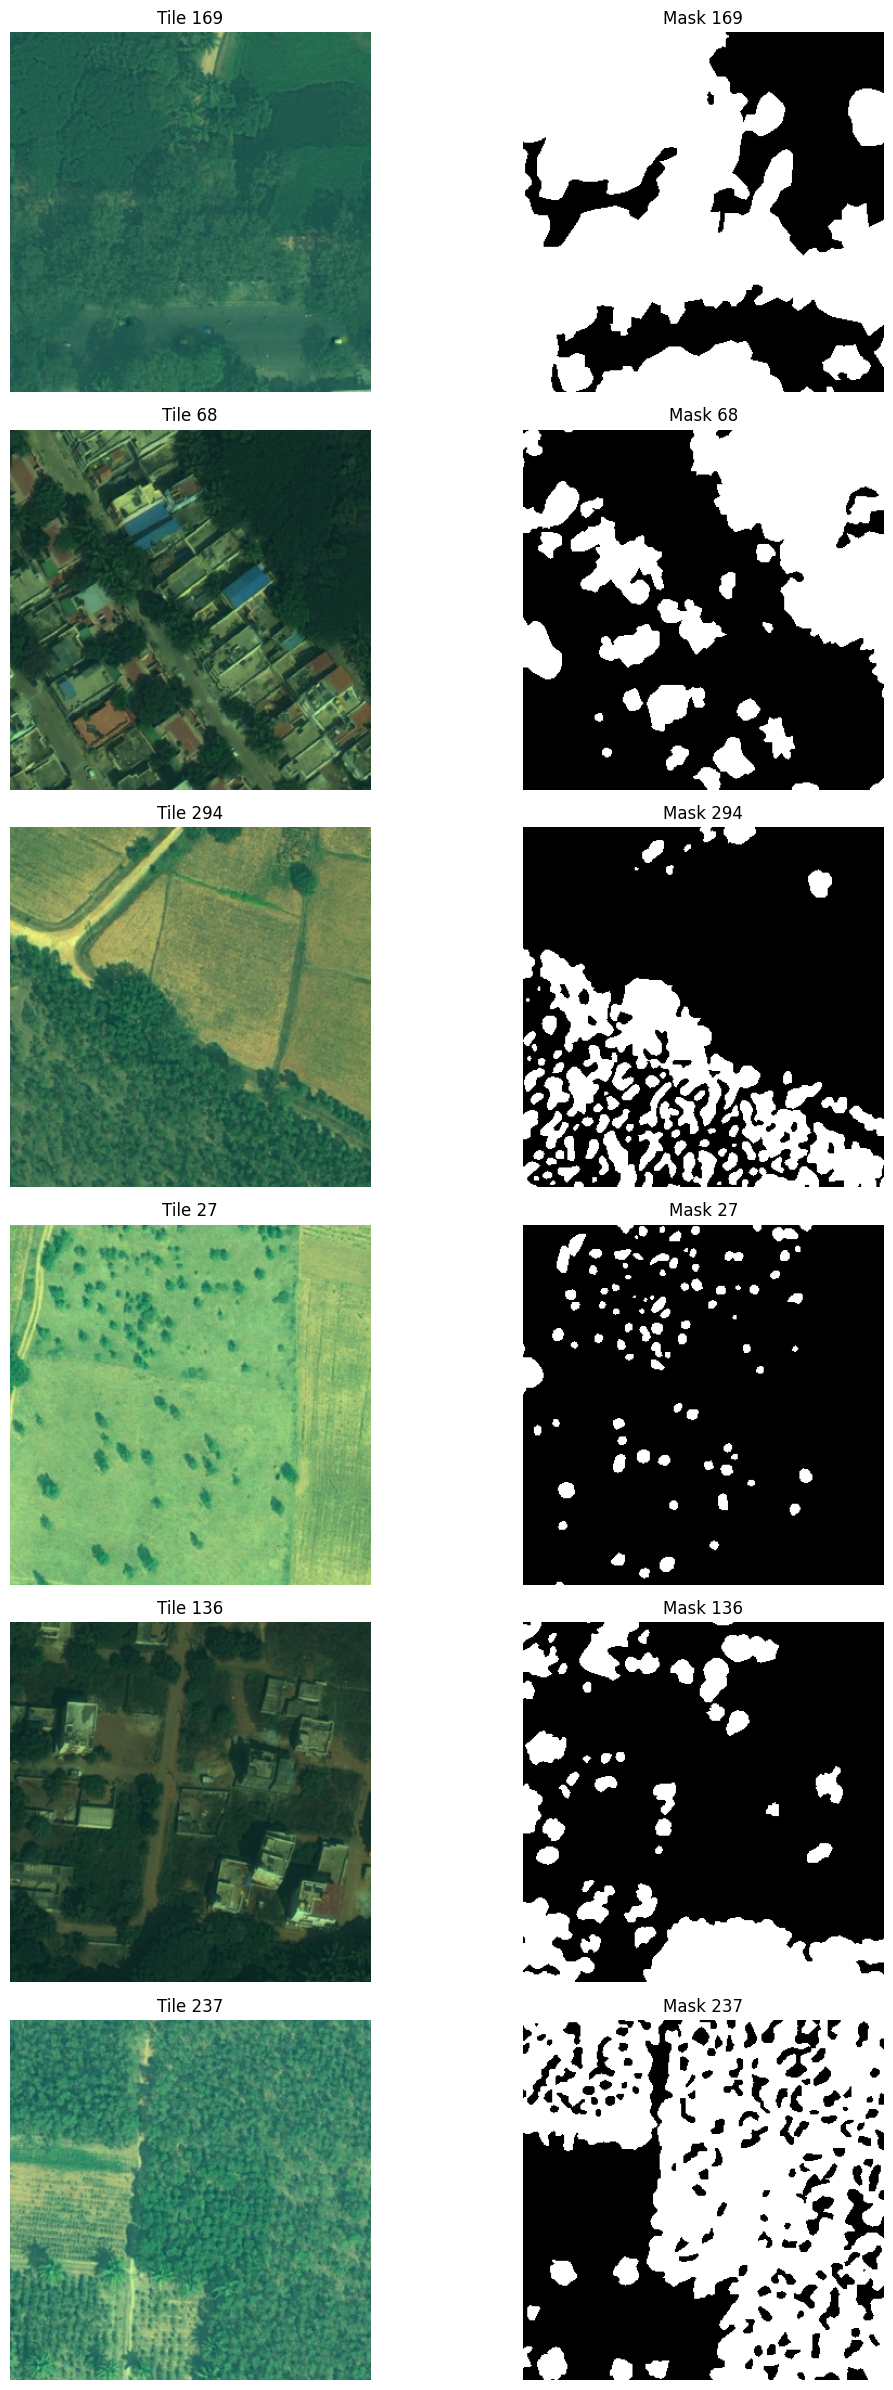

Image shape: (333, 333, 7)
Mask shape: (333, 333)
Mask unique values: [0 1]


In [ ]:
plt.figure(figsize=(12, 24))

for i, tile_path in enumerate(selected_files):

    idx = tile_path.stem.split("_")[1]
    mask_path = masks_path / f"mask_{idx}.tif"

    with rasterio.open(tile_path) as src:
        image = src.read().astype(np.float32)   # (C, H, W)
        image = np.transpose(image, (1, 2, 0))  # (H, W, C)

    with rasterio.open(mask_path) as src:
        mask = src.read(1)

    # pseudo-RGB
    rgb = image[:, :, [3, 1, 0]]
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

    plt.subplot(6, 2, 2*i + 1)
    plt.imshow(rgb)
    plt.title(f"Tile {idx}")
    plt.axis("off")

    plt.subplot(6, 2, 2*i + 2)
    plt.imshow(mask, cmap="gray")
    plt.title(f"Mask {idx}")
    plt.axis("off")

plt.tight_layout()
plt.show()
print("Image shape:", image.shape)
print("Mask shape:", mask.shape)
print("Mask unique values:", np.unique(mask))



overlay image + masque

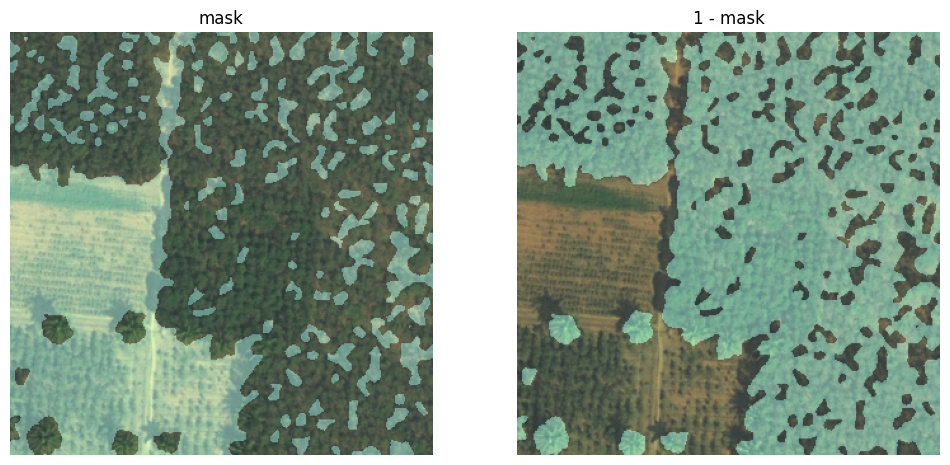

In [ ]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(rgb)
plt.imshow(mask, cmap="Reds", alpha=0.35)
plt.title("mask")

plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(rgb)
plt.imshow(1 - mask, cmap="Reds", alpha=0.35)
plt.title("1 - mask")
plt.axis("off")

plt.show()

Visualization of all channels for a random picture

In [ ]:
#Display of all channels for 1 picture
selected_file = random.sample(tile_files, 1)


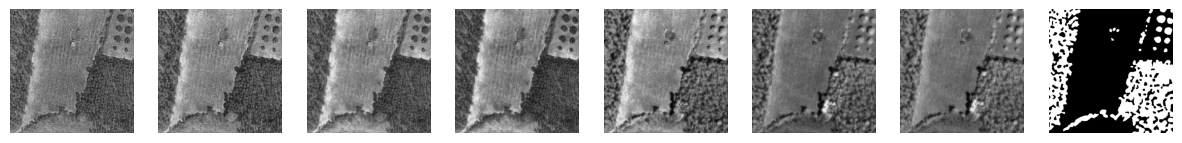

[0 1]


In [ ]:
tile_path = selected_file[0]
idx = tile_path.stem.split("_")[1]
mask_path = masks_path / f"mask_{idx}.tif"
with rasterio.open(tile_path) as src:
        image = src.read()

with rasterio.open(mask_path) as src:
        mask = src.read(1)
        mask

fig,ax = plt.subplots(1,8 , figsize=(15,5))

for index in range(7) :
  if index <= 6 :
    band = image[index]
    band = (band - band.min()) / (band.max() - band.min() + 1e-8)
    ax[index].imshow (band, cmap = 'gray')
    ax[index].axis('off')
  ax[7].imshow (mask , cmap = 'gray')
  ax[7].axis('off')
plt.show()
print(np.unique(mask))